<a href="https://colab.research.google.com/github/mmdsadra/Credit-Approval/blob/main/SVM_project_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#for reading the csv file and displaying info
# Notice that the file will be downloaded
url = "https://raw.githubusercontent.com/mmdsadra/Credit-Approval/refs/heads/Sadra-17-12/crx.csv"
main_df = pd.read_csv(url, header=None)
main_df.shape
main_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43,560,+
2,a,24.5,0.500,u,g,q,h,1.50,t,f,0,f,g,280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120,0,+


In [ ]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    object 
 1   1       690 non-null    object 
 2   2       690 non-null    float64
 3   3       690 non-null    object 
 4   4       690 non-null    object 
 5   5       690 non-null    object 
 6   6       690 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      690 non-null    object 
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


In [ ]:
#for replacing missing values
main_df = main_df.replace('?', np.nan)

In [ ]:
main_df.nunique()

,0
0,2
1,349
2,215
3,3
4,3
5,14
6,9
7,132
8,2
9,2


In [ ]:
df = main_df

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       678 non-null    object 
 1   1       678 non-null    object 
 2   2       690 non-null    float64
 3   3       684 non-null    object 
 4   4       684 non-null    object 
 5   5       681 non-null    object 
 6   6       681 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      677 non-null    object 
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


In [ ]:
df.describe()

,2,7,10,14
count,690.000000,690.000000,690.00000,690.000000
mean,4.758725,2.223406,2.40000,1017.385507
std,4.978163,3.346513,4.86294,5210.102598
min,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.165000,0.00000,0.000000
50%,2.750000,1.000000,0.00000,5.000000
75%,7.207500,2.625000,3.00000,395.500000
max,28.000000,28.500000,67.00000,100000.000000


In [ ]:
def is_num(x):
    try:
        float(x)
        return True
    except ValueError:
        return False

def normalize_array(arr):# it is scaled not normal, normal is (x-x_bar)/ sigma
    tmp = arr.copy()
    min = tmp.min()
    max = tmp.max()
    dis = max - min
    arr_len = len(tmp)
    for i in range (arr_len):
        tmp[i] -= min
        tmp[i] /= dis
    return tmp

# converting all columns to numbers and normalize them (preprocessing dataset)
def convert_normalize_data(df):
    for i in range (df.shape[1]):
        if (df[i].dtype == float or df[i].dtype == int):
            df[i] = df[i].astype(float)
            df[i] = normalize_array(df[i])
            continue
        c = df[i].mode().values[0]
        if (type(c) == int or type(c) == float or is_num(c)):
            df[i] = pd.to_numeric(df[i], errors='coerce')
            if (df[i].isna().any()):
                avg = np.nanmedian(df[i])
                df[i] = df[i].where(df[i].notna(), avg)
                df.iloc[:, i] = normalize_array(df[i])
        else:
            df[i] = df[i].where(df[i].notna(), c)
            u_arr = df[i].unique()
            n_arr = np.arange(len(u_arr))
            n_arr = normalize_array(n_arr)
            mapping = dict(zip(u_arr, n_arr))
            df[i] = df[i].map(mapping)
    return df

#df = convert_normalize_data(df)

In [ ]:
def TrueNormalizer(arr):
    tmp = arr.astype(float).copy()
    mean = np.mean(tmp)
    std = np.std(tmp)

    if std == 0:
        return np.zeros_like(tmp)

    return (tmp - mean) / std

def correct_convert_normalize_data(df):
    for i in range(df.shape[1]):
        if df[i].dtype == float or df[i].dtype == int:
            df[i] = df[i].astype(float)
            df[i] = TrueNormalizer(df[i])
            continue

        c = df[i].mode().values[0]

        if isinstance(c, (int, float)) or is_num(c):
            df[i] = pd.to_numeric(df[i], errors='coerce')
            if df[i].isna().any():
                avg = np.nanmedian(df[i])
                df[i] = df[i].fillna(avg)
            df[i] = TrueNormalizer(df[i])


        else:
            df[i] = df[i].fillna(c)
            u_arr = df[i].unique()
            n_arr = np.arange(len(u_arr), dtype=float)
            n_arr = TrueNormalizer(n_arr)
            mapping = dict(zip(u_arr, n_arr))
            df[i] = df[i].map(mapping)
    return df

df = correct_convert_normalize_data(df)

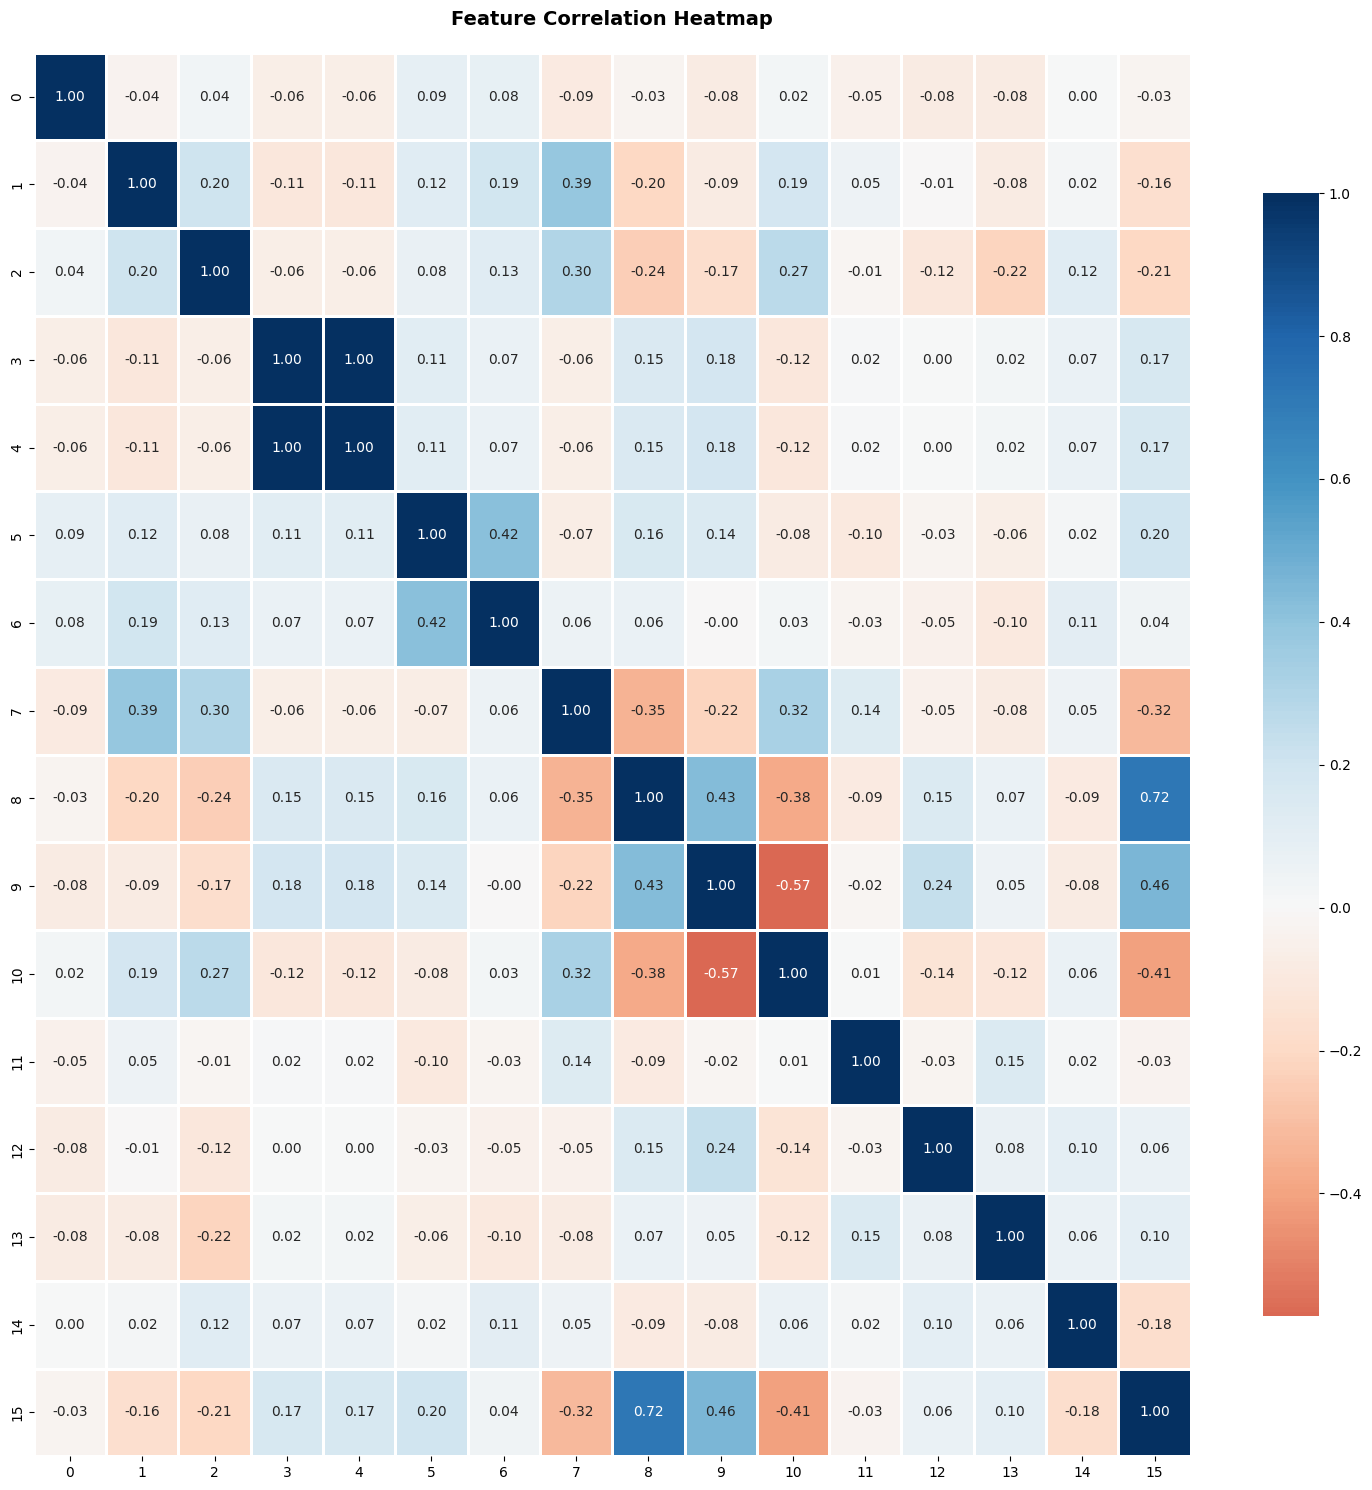


Top correlations with result column:
8     0.720407
9     0.458301
10   -0.406410
7    -0.322475
2    -0.206294
5     0.196453
14   -0.175657
3     0.169623
4     0.169623
1    -0.164086
13    0.100042
12    0.063556
6     0.044521
11   -0.031625
0    -0.028934
Name: 15, dtype: float64


In [ ]:
# displaying correlations with heatmap
plt.figure(figsize=(15, 15))
correlation = main_df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdBu', center=0, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nTop correlations with result column:")
outcome_corr = correlation[15].sort_values(key=abs, ascending=False)
print(outcome_corr[1:])

In [ ]:
df = df.drop([3,4,12,5,11,0,6], axis = 1)
df.columns = list(range(df.shape[1]))
df

,0,1,2,3,4,5,6,7,8
0,-0.057723,-0.956613,-0.291083,-1.0,-1.0,-0.288101,0.107155,-0.195413,-1.0
1,2.291317,-0.060051,0.244190,-1.0,-1.0,0.740830,-0.816912,-0.087852,-1.0
2,-0.591826,-0.856102,-0.216324,-1.0,1.0,-0.493887,0.560471,-0.037144,-1.0
3,-0.310853,-0.647038,0.456505,-1.0,-1.0,0.535044,-0.485643,-0.194837,-1.0
4,-0.957176,0.174141,-0.153526,-1.0,1.0,-0.493887,-0.369408,-0.195413,-1.0
...,...,...,...,...,...,...,...,...,...
685,-0.880394,1.070704,-0.291083,1.0,1.0,-0.493887,0.444236,-0.195413,1.0
686,-0.746235,-0.805846,-0.066806,1.0,-1.0,-0.082314,0.095532,-0.119736,1.0
687,-0.528544,1.757198,-0.066806,1.0,-1.0,-0.288101,0.095532,-0.195221,1.0
688,-1.147023,-0.915403,-0.652915,1.0,1.0,-0.493887,0.560471,-0.051358,1.0


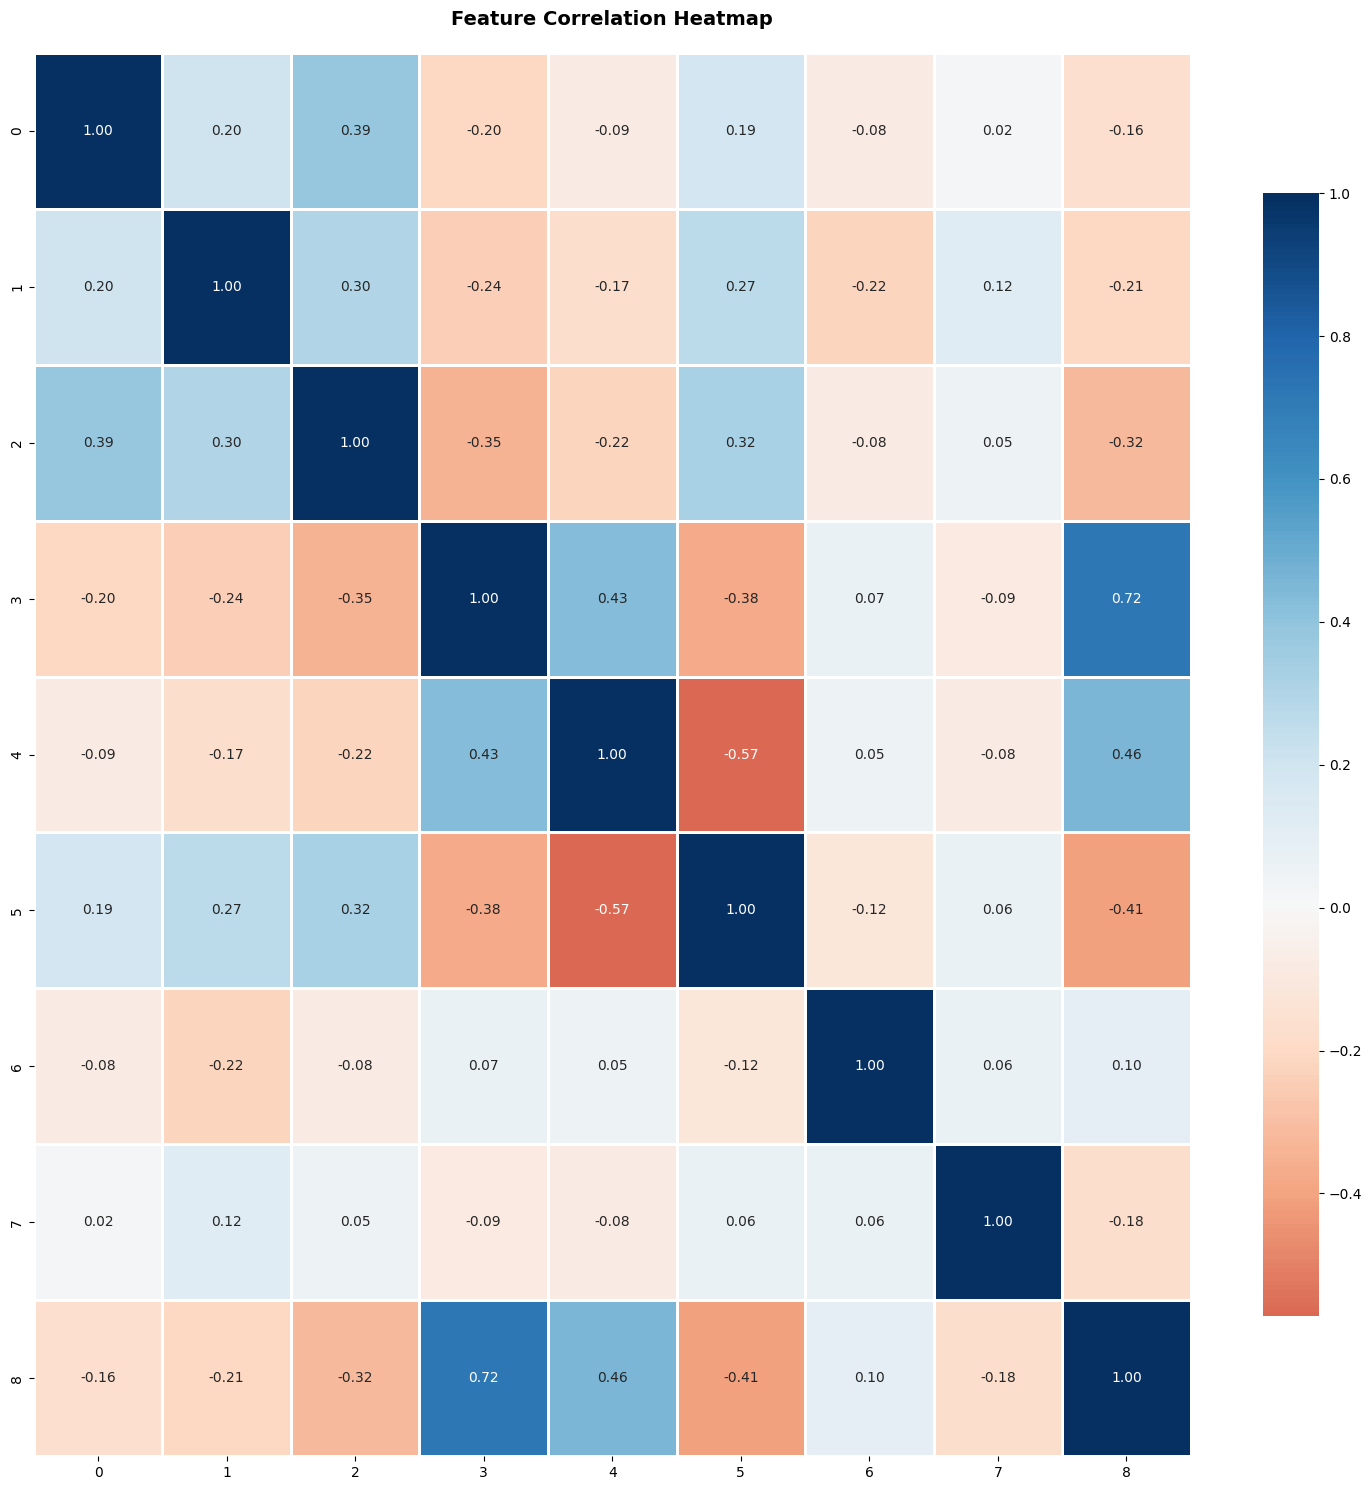


Top correlations with result column:
3    0.720407
4    0.458301
5   -0.406410
2   -0.322475
1   -0.206294
7   -0.175657
0   -0.164086
6    0.100042
Name: 8, dtype: float64


In [ ]:
# displaying correlations with heatmap
plt.figure(figsize=(15, 15))
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdBu', center=0, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nTop correlations with result column:")
outcome_corr = correlation[8].sort_values(key=abs, ascending=False)
print(outcome_corr[1:])

# Logistic Regresion

In [ ]:
# seperating test datas and input datas
# test_data = df[590:][:].reset_index(drop=True)
# train_df = df[:590 ][:]
test_data = pd.concat([
    df.iloc[:20],
    df.iloc[-20:]
]).sample(frac = 1).reset_index(drop=True)
train_df = df.iloc[20:-20].reset_index(drop=True)

#SVM

In [ ]:

def train_svm(X, y, lr=0.001, lambda_param=0.01, epochs=1000):
    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    b = 0

    for epoch in range(epochs):
        for i in range(n_samples):

            condition = y[i] * (np.dot(X[i], w) + b) >= 1

            if condition:

                w = w - lr * (2 * lambda_param * w)
            else:
                # hinge loss gradient !!! < ------------ !!! < -----------------
                w = w - lr * (2 * lambda_param * w - y[i] * X[i])
                b = b - lr * (-y[i])

    return w, b

def svm_predict(X, w, b):
    linear_output = np.dot(X, w) + b
    predictions = np.sign(linear_output)
    return predictions

In [ ]:
#getting features and labels for input_data
features = train_df.iloc[:, :-1]
labels = train_df.iloc[:, -1]
features

,0,1,2,3,4,5,6,7
0,-0.549638,1.304896,0.082711,-1.0,-1.0,3.004477,0.095532,0.036612
1,-0.697297,-0.755590,-0.415182,-1.0,1.0,-0.493887,0.676706,-0.195413
2,1.369926,0.651571,1.690026,-1.0,-1.0,0.740830,-1.066817,0.046600
3,-0.345447,1.958221,0.257647,-1.0,-1.0,-0.288101,-0.369408,-0.193301
4,0.814729,0.350036,-0.515359,-1.0,-1.0,0.123472,-0.224114,-0.195413
...,...,...,...,...,...,...,...,...
645,0.026653,-0.948572,-0.652915,1.0,1.0,-0.493887,-1.066817,-0.195413
646,-0.823862,1.405407,-0.590118,1.0,1.0,-0.493887,-0.020703,-0.195413
647,-1.147023,-0.848061,-0.141565,1.0,-1.0,-0.288101,-0.601877,-0.194453
648,-0.099912,-0.856102,-0.639459,1.0,1.0,-0.493887,0.397742,-0.195413


In [ ]:
#logistic regression variables and algorithm

epoches = 5000
learning_rate = 0.1
cost_history = []
thetas = np.zeros(features.shape[1])
bias = 0

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logreg_compute_gradiant(features, lables, thetas, bias):
    m, n = features.shape
    z = np.dot(features, thetas) + bias
    predictions = sigmoid(z)
    dw = (1/m) * np.dot(features.T, (predictions - lables))
    db = (1/m) * np.sum(predictions - lables)
    thetas = thetas - learning_rate * dw
    bias = bias - learning_rate * db
    return thetas, bias

def logreg_compute_cost(features, lables, thetas, bias):
    m = len(lables)
    z = np.dot(features, thetas) + bias
    prediction = sigmoid(z)
    epsilon = 1e-15
    prediction = np.clip(prediction, epsilon, 1 - epsilon)
    cost = -np.mean(lables * np.log(prediction) + (1-lables) * np.log(1-prediction))
    return cost

for epoch in range (epoches):
    thetas, bias = logreg_compute_gradiant(features, labels, thetas, bias)
    cost = logreg_compute_cost(features, labels, thetas, bias)
    cost_history.append(cost)

thetas

Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
/tmp/ipython-input-2486384576.py:10: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipython-input-2486384576.py:10: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipython-input-2486384576.py:10: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipython-input-2486384576.py:10: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipython-input-2486384576.py:10: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipython-input-2486384576.py:10: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipython-input-2486384576.py:10: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipython-input-2486384576.py:10: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipython-input-2486384576.py:10: RuntimeW

array([ -29.01987602,  -41.78270367,  -80.85593833,  141.66998726,
         79.48133099, -112.33223707,   21.24299016,  -54.88645801])

In [ ]:
print("features shape:", features.shape)
print("labels shape:", labels.shape)

features shape: (650, 8)
labels shape: (650,)


In [ ]:
X = features.to_numpy()
y = labels.to_numpy()

thetas, bias = train_svm(X, y)

In [ ]:
thetas

array([ 2.29079001e-04,  3.95105678e-03, -1.25611823e-02,  1.00039984e+00,
        1.16211810e-02, -8.98469061e-03,  8.34583043e-03, -1.04801946e-01])

In [ ]:
# getting features and labels for test datas
test_features = test_data.iloc[:, :8]
test_labels = test_data.iloc[:, 8]

In [ ]:
# precision for input_data
#z = np.dot(features, thetas) + bias
#predictions = sigmoid(z)
predictions = svm_predict(test_features.to_numpy(), thetas, bias)
success = 0
for i in range (len(predictions)):
    if (predictions[i] >= 0.5):
        if (labels[i] <= 1):
            success += 1
    else:
        if (labels[i] <= 0):
            success += 1
print("success rate :", success / len(predictions) * 100)
predictions

success rate : 100.0


array([-1., -1.,  1.,  1.,  1., -1., -1., -1.,  1.,  1.,  1., -1.,  1.,
        1., -1.,  1., -1.,  1.,  1.,  1., -1., -1.,  1.,  1., -1., -1.,
       -1.,  1.,  1.,  1.,  1., -1., -1.,  1.,  1., -1.,  1., -1., -1.,
        1.])

In [ ]:
# precision for test datas
z_reg = np.dot(test_features, thetas) + bias
predictions_reg = sigmoid(z)
success_reg = 0
for i in range (len(predictions_reg)):
    if (predictions_reg[i] >= 0.5):
        if (test_labels[i] >= 1):
            success_reg += 1
    else:
        if (test_labels[i] <= 0):
            success_reg += 1
print("success rate :", success_reg / len(predictions_reg) * 100)

success rate : 95.0


In [ ]:
for i in range (len(predictions)):
    if (predictions[i] >= 0.5):
        predictions[i] = 1
    else:
        predictions[i] = 0
predictions

array([0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 1., 0.,
       1., 1., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1.,
       1., 0., 1., 0., 0., 1.])

In [ ]:
# displayign confusion matrix
y_true = test_labels
y_pred = predictions
y_true = np.array(y_true)
y_pred = np.array(y_pred)

TP = np.sum((y_true == 1) & (y_pred == 1))
TN = np.sum((y_true == 0) & (y_pred == 0))
FP = np.sum((y_true == 0) & (y_pred == 1))
FN = np.sum((y_true == 1) & (y_pred == 0))

print(TP, TN, FP, FN)

20 0 0 0
